In [1]:
# %pip install git+https://github.com/Mishne-Lab/pyRATS
# if not already installed on the system:
# %pip install pandas imageio seaborn matplotlib

import sys
sys.path.insert(0, '../src/')
sys.path.insert(0, '../')

from pyRATS import rats
from examples import vis

matplotlib.get_backend() =  module://matplotlib_inline.backend_inline


# Load data

Note that the data loaded here is from the following paper:
Gardner, R. J., Hermansen, E., Pachitariu, M., Burak, Y., Baas, N. A., Dunn, B. A., Moser, M.-B., & Moser, E. I. (2022). Toroidal topology of population activity in grid cells. Nature, 602(7895), 123–128. https://doi.org/10.1038/s41586-021-04268-7

In [2]:
import os
import pickle

def path_exists(path):
    return os.path.exists(path) or os.path.islink(path)

def read(fpath, verbose=True):
    if not path_exists(fpath):
        if verbose:
            print(fpath, 'does not exist.')
        return None
    with open(fpath, "rb") as f:
        data = pickle.load(f)
    if verbose:
        print('Read data from', fpath, flush=True)
    return data
    

In [3]:
data_fname = '../data/r2of_data.dat'         # PATH TO DATA
X, labels, metadata = read(data_fname)


Read data from ../../../RATS/code/R2OFday1/notebooks/data/data.dat


# Generate embeddings

In [4]:
model = rats.RATS(
    n_components=2, 
    kernel='cosine', 
    n_neighbors=34, 
    cost_function='distortion', 
    min_cluster_size=3, 
    metric='cosine',
    n_iter_without_progress=20,
    tree='mst',
    root_view= 'largest',
    tear=True,
)
y = model.fit_transform(X)

/tmp/ipykernel_10522/4200613334.py:1: FutureWarning: metric='cosine' is not yet fully supported. Only 'euclidean' is used in the embedding step. This parameter will be extended in a future release.
  model = rats.RATS(


/data2/dhruv/RATS_code/Jun_16_MishneLab_PyRATS/pyRATS/examples/../examples/vis.py:2058: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


<Axes: >

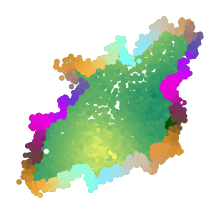

In [5]:
tear_color_eig_inds = [5, 1, 3] # interior has green color so assigned smallest value of i to g-channel
color_of_pts_on_tear = model.compute_color_of_pts_on_tear(
    y,
    tear_color_eig_inds=tear_color_eig_inds,
)
vis.Visualize().global_embedding(
    y, labels[:,0],
    color_of_pts_on_tear=color_of_pts_on_tear[:,tear_color_eig_inds] if color_of_pts_on_tear is not None else None,
    cmap0='summer',
    cmap1='jet',
    title='color='+str(tear_color_eig_inds),
    figsize=(2,2)
)

<Axes: >

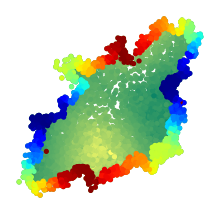

In [6]:
tear_color_eig_inds = [1] # interior has green color so assigned smallest value of i to g-channel
color_of_pts_on_tear = model.compute_color_of_pts_on_tear(
    y,
    tear_color_eig_inds=tear_color_eig_inds,
)
vis.Visualize().global_embedding(
    y, labels[:,0],
    color_of_pts_on_tear=color_of_pts_on_tear[:,tear_color_eig_inds] if color_of_pts_on_tear is not None else None,
    cmap0='summer',
    cmap1='jet',
    title='color='+str(tear_color_eig_inds),
    figsize=(2,2)
)

To regularize the tear, we save the data and use the cut-and-paste app (Extended data figure 1). 
To run the app, execute:
- bokeh serve cut_and_paste_app.py --allow-websocket-origin=localhost:5006
- then go to http://localhost:5006

In [7]:
def save(dirpath, fname, data, verbose=True):
    if not path_exists(dirpath):
        os.makedirs(dirpath)
    fpath = dirpath + '/' + fname
    with open(fpath, "wb") as f:
        pickle.dump(data, f)
    if verbose:
        print('Saved data in', fpath, flush=True)
        
emb_info = {
    'y': y,
    'color_of_pts_on_tear': color_of_pts_on_tear,
    'model': model,
}
metadata = {
    'algo': 'rats',
    'hyperparameters': {
        'd': 2,
    },
}
save('./generated_data/rats/34_3/', 'rats.dat', [emb_info, metadata])

Saved data in ./generated_data/rats/34_3//rats.dat
